# HOMEWORK 9

In this homework, you are going to use the dlib face detector and apply it to an image of your liking. You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-)

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [1]:
# Step 0: Import the libraries required for this task.
#
# dlib       -> provides the pre-trained face detector

import cv2
import dlib
import numpy as np
import matplotlib.pyplot as plt

### Step 1

Load an image (any image that contains faces).

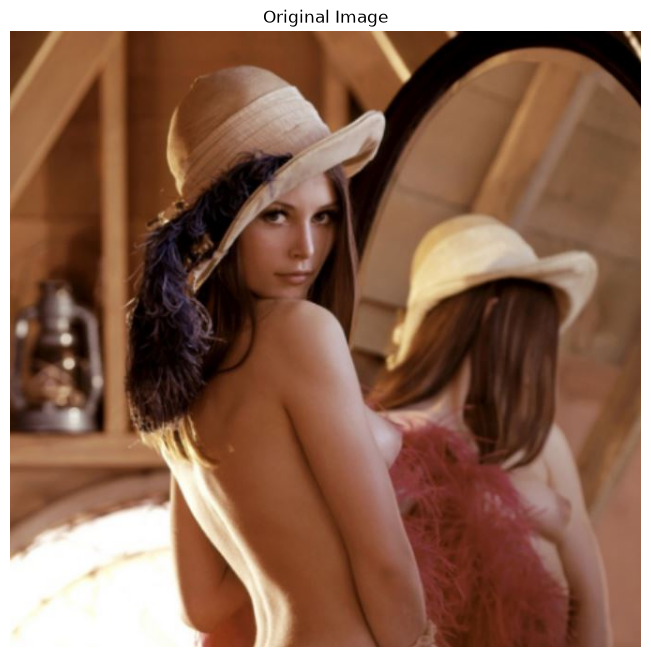

In [2]:
# Step 1: Load an image containing one or more faces.

image_path = "Lenna_Top.JPG"
# Load_rgb_image function, passing as input the path to the image, as a string. -->
# As output, this function will return a ndarray representing the image.
image = dlib.load_rgb_image(image_path)
# Now that we loaded our image, we will create an object of class image_window, which will allow us to display our image and the facial landmarks detected
win = dlib.image_window(image, "Image")  
# Display the original image here
plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

### Step 2

Load the dlib face detector.

In [3]:
# This detector is based on the Histogram of Oriented Gradients (HOG) + comb. wth linear classifier -->
# and it can detect frontal faces without requiring us to train a model.

detector = dlib.get_frontal_face_detector()

print("dlib face detector loaded successfully.")

dlib face detector loaded successfully.


### Step 3

Run the detector on your image.

In [4]:
# Run the detector.
# The second argument (1) is the number of image pyramid upsampling
# times (min_neibors in your ). A value of 1 can help detect smaller faces, at the cost
# of additional computation.
faces = detector(image, 1)

print(f"Number of faces detected: {len(faces)}")

# Print the bounding-box coordinates for each detected face.
# Each rectangle contains:
# left, top, right, bottom coordinates.

for i, face in enumerate(faces, start=1):
    print(
        f"Face {i}: "
        f"left={face.left()}, "
        f"top={face.top()}, "
        f"right={face.right()}, "
        f"bottom={face.bottom()}"
    )

Number of faces detected: 1
Face 1: left=239, top=153, right=368, bottom=282


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

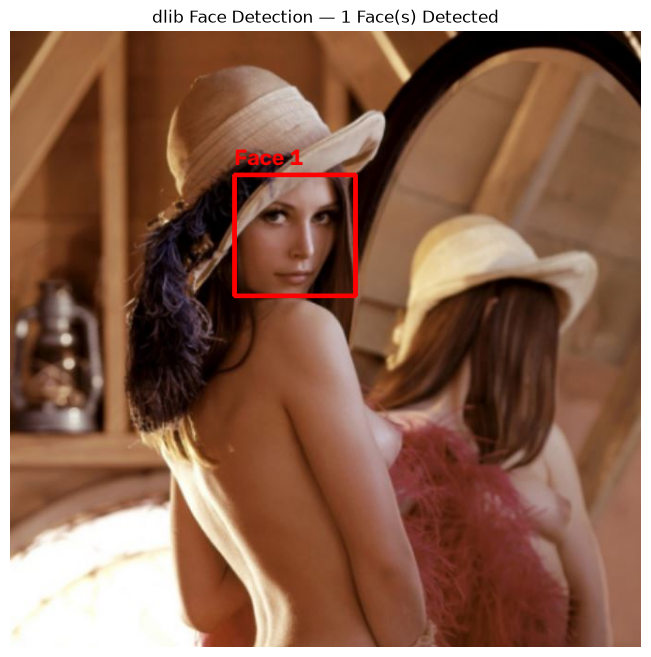

In [5]:
# Draw a bounding box around every detected face (We had only one face, but I wrote code below for common case)

# We create a copy of the original image so that the original
# image remains unchanged.

result_image = image.copy()

# Define several colours in RGB format.
# If there are more faces than colours, we cycle through the list.

colours = [
    (255, 0, 0),      # Red
    (0, 255, 0),      # Green
    (0, 0, 255),      # Blue
    (255, 165, 0),    # Orange
    (255, 0, 255),    # Magenta
    (0, 255, 255),    # Cyan
]

# Draw the bounding box for every detected face.
for i, face in enumerate(faces):
    
    # Get the bounding-box coordinates.
    x1 = face.left()
    y1 = face.top()
    x2 = face.right()
    y2 = face.bottom()

    # Select a colour for this particular face.
    colour = colours[i % len(colours)]

    # Draw the rectangle.
    cv2.rectangle(
        result_image,
        (x1, y1),
        (x2, y2),
        colour,
        thickness=3
    )

    # Add a label showing the detected face number.
    cv2.putText(
        result_image,
        f"Face {i + 1}",
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        colour,
        2,
        cv2.LINE_AA
    )

# Display the final result.
plt.figure(figsize=(12, 8))
plt.imshow(result_image)
plt.axis("off")
plt.title(f"dlib Face Detection — {len(faces)} Face(s) Detected")
plt.show()


In [6]:

# we can also draw them on top of the image window by calling the add_overlay method on the image_window object, 
win.add_overlay(faces)
#  After this we will create an object of class shape_predictor, which will allow us to detect the face landmarks
predictor = dlib.shape_predictor("shape_predictor_5_face_landmarks.dat") # The 5 landmarks model identifies the corners of the eyes and bottom of the nose 
# predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat") # he 68 landmarks model identifies the following parts of the face -->
# Jaw (from ear to ear)
# Nose
# Left eyebrow
# Right eyebrow
# Left eye
# Right eye
# Mouth
# But size is large and I only tried it at my PC - Works realy nice [I've attached screenshot]
for face in faces:
    landmarks = predictor(image, face)
    win.add_overlay(landmarks)
 
win.wait_until_closed()

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

dlib face detector loaded successfully.
Number of faces detected: 1


<Figure size 1200x800 with 0 Axes>

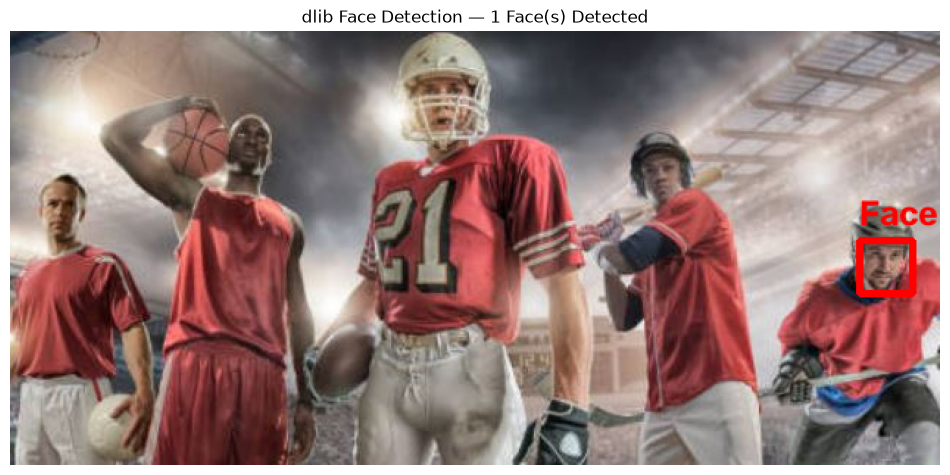

In [7]:
image_path = "amer_socker.JPG"
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
detector = dlib.get_frontal_face_detector()
print("dlib face detector loaded successfully.")
gray_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
faces = detector(gray_image, 1)
print(f"Number of faces detected: {len(faces)}")
res_image = image_rgb.copy()
# Draw the bounding box for every detected face.
for i, face in enumerate(faces):
    
    # Get the bounding-box coordinates.
    x1 = face.left()
    y1 = face.top()
    x2 = face.right()
    y2 = face.bottom()

    # Select a colour for this particular face.
    colour = colours[i % len(colours)]

    # Draw the rectangle.
    cv2.rectangle(
        res_image,
        (x1, y1),
        (x2, y2),
        colour,
        thickness=3
    )

    # Add a label showing the detected face number.
    cv2.putText(
        res_image,
        f"Face {i + 1}",
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        colour,
        2,
        cv2.LINE_AA
    )

# Display the final result.
plt.figure(figsize=(12, 8))
plt.imshow(res_image)
plt.axis("off")
plt.title(f"dlib Face Detection — {len(faces)} Face(s) Detected")
plt.show()

How does the detector perform? Is it robust? -- Worse! Color of skin, helmet and even luminarity influences a lot, so detector doesn`t robust!